# Credit Card Fraud Detection

## (1) Import Libraries & Setup

In [6]:
# Core libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, 
                             roc_auc_score, precision_recall_curve, average_precision_score)

# Models
from xgboost import XGBClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE

# Feature selection
from sklearn.feature_selection import mutual_info_classif

# Hyperparameter optimisation
import optuna

## (2) Data Loading & Overview

In [7]:
# Load the data
df = pd.read_csv("C:/Users/user/Python Projects/creditcard.csv")

In [8]:
# Data overview
print(df.head())
print(df.info())

# Check for missing values
missing = df.isnull().sum()
print("Missing Values Analysis")
print("=" * 60)
print(f"Total Missing: {missing.sum()}")
if missing.sum() == 0:
    print("No missing values found!")

# Check and drop for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate Records: {duplicates:,} ({(duplicates/len(df))*100:.2f}%)")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"New dataset shape: {df.shape[0]:,} rows")

df.duplicated().sum() # ensure duplicates are removed

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

np.int64(0)

## (3) Exploratory Data Analysis

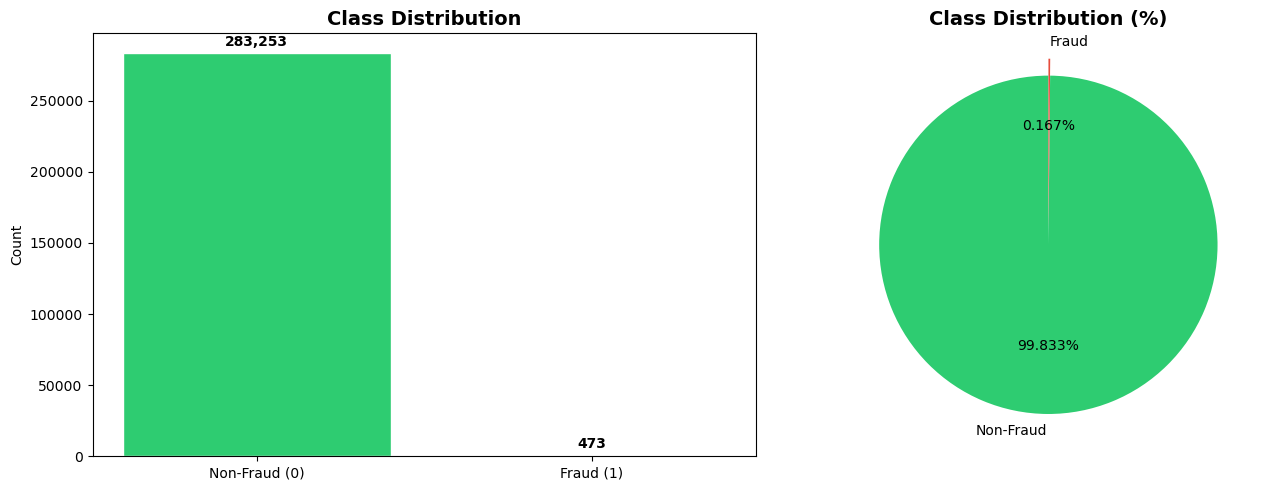

Non-Fraud: 283,253 (99.833%)
Fraud: 473 (0.167%)
Imbalance Ratio: 599:1


In [9]:
# Class distribution analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
class_counts = df['Class'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Non-Fraud (0)', 'Fraud (1)'], class_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, count in enumerate(class_counts.values):
    axes[0].text(i, count + 5000, f'{count:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Non-Fraud', 'Fraud'], autopct='%1.3f%%', 
            colors=colors, explode=(0, 0.1), startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Non-Fraud: {class_counts[0]:,} ({class_counts[0]/len(df)*100:.3f}%)")
print(f"Fraud: {class_counts[1]:,} ({class_counts[1]/len(df)*100:.3f}%)")
print(f"Imbalance Ratio: {class_counts[0]/class_counts[1]:.0f}:1")

##### This dataset is highly imbalanced (0.167% fraud), posing a significant challenge for model performance.

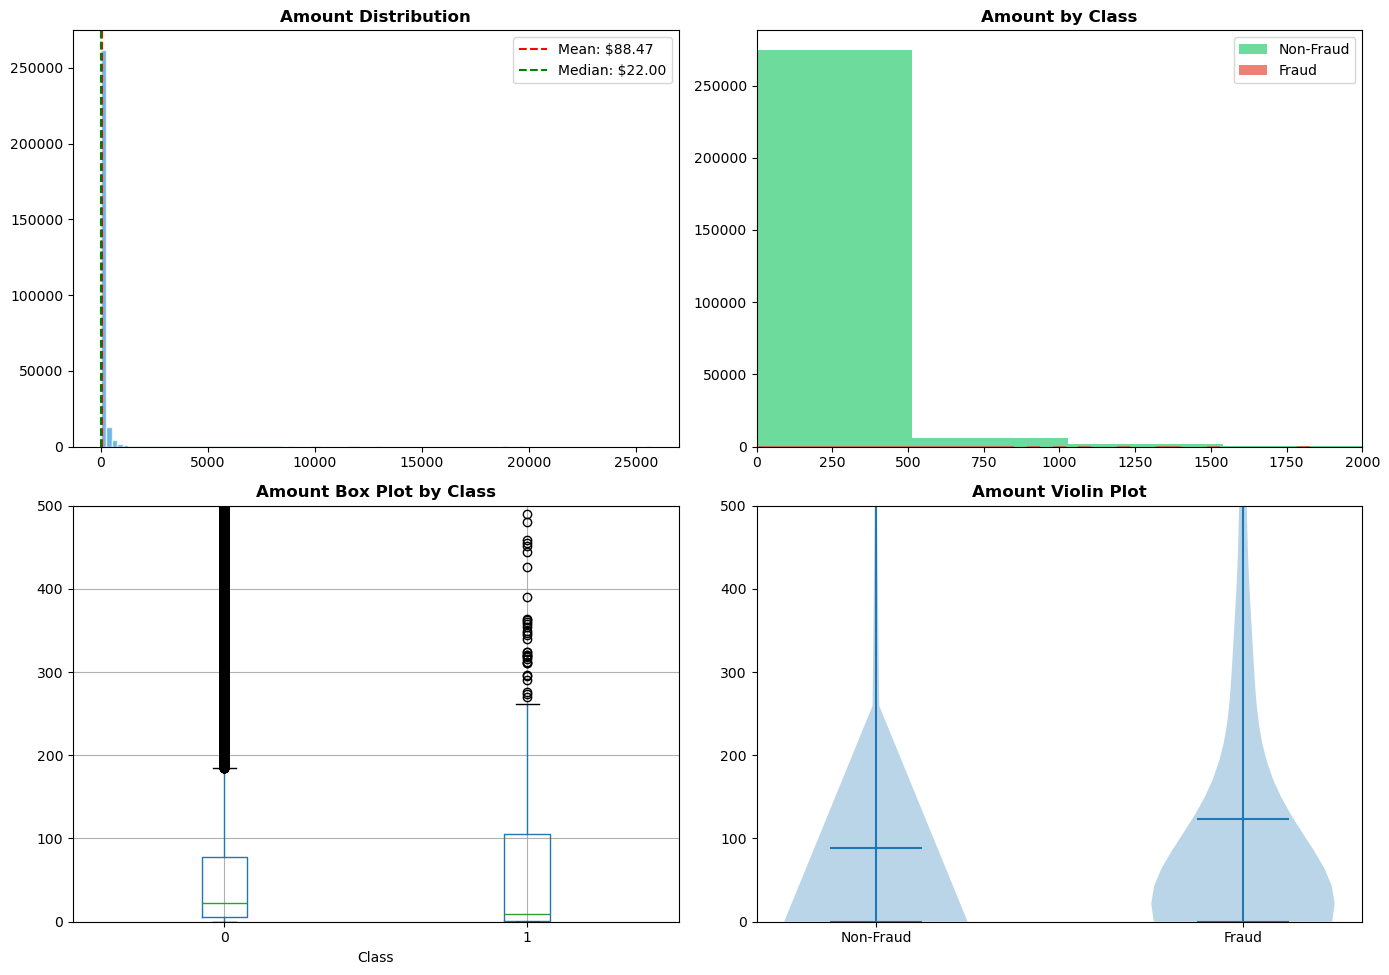

In [10]:
# Transaction amount analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution
axes[0,0].hist(df['Amount'], bins=100, color='#3498db', edgecolor='white', alpha=0.7)
axes[0,0].axvline(df['Amount'].mean(), color='red', linestyle='--', label=f'Mean: ${df["Amount"].mean():.2f}')
axes[0,0].axvline(df['Amount'].median(), color='green', linestyle='--', label=f'Median: ${df["Amount"].median():.2f}')
axes[0,0].set_title('Amount Distribution', fontweight='bold')
axes[0,0].legend()

# Amount by Class
axes[0,1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, label='Non-Fraud', color='#2ecc71')
axes[0,1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, label='Fraud', color='#e74c3c')
axes[0,1].set_title('Amount by Class', fontweight='bold')
axes[0,1].legend()
axes[0,1].set_xlim(0, 2000)

# Box plot
df.boxplot(column='Amount', by='Class', ax=axes[1,0])
axes[1,0].set_title('Amount Box Plot by Class', fontweight='bold')
axes[1,0].set_ylim(0, 500)
plt.suptitle('')

# Violin plot
fraud_amt = df[df['Class']==1]['Amount']
non_fraud_amt = df[df['Class']==0]['Amount']
parts = axes[1,1].violinplot([non_fraud_amt, fraud_amt], positions=[0, 1], showmeans=True)
axes[1,1].set_xticks([0, 1])
axes[1,1].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[1,1].set_title('Amount Violin Plot', fontweight='bold')
axes[1,1].set_ylim(0, 500)

plt.tight_layout()
plt.show()

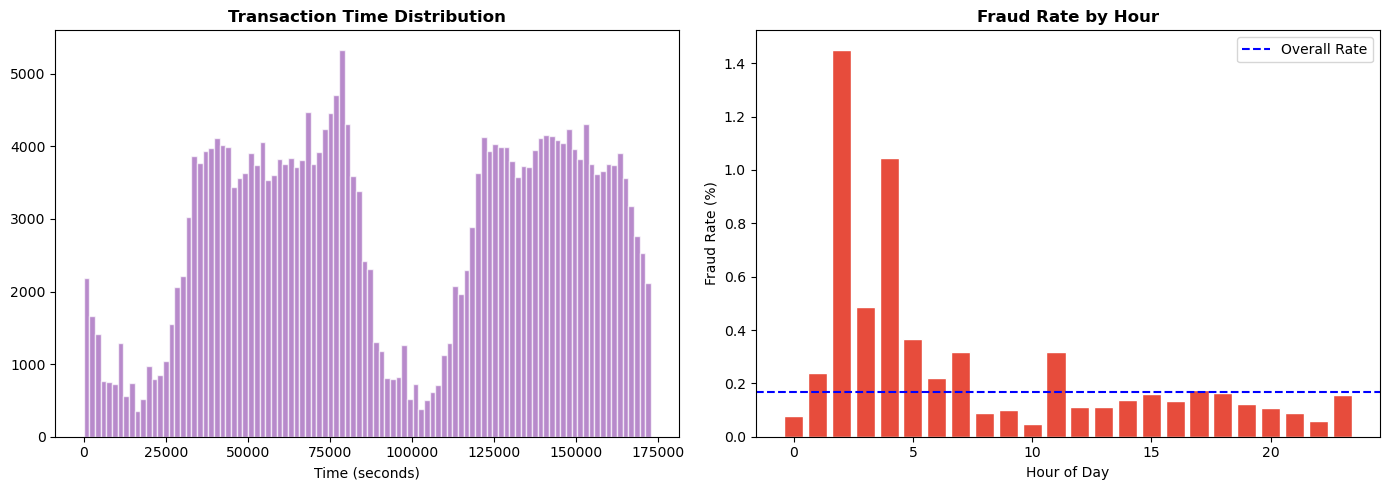

In [11]:
# Time analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time distribution
axes[0].hist(df['Time'], bins=100, color='#9b59b6', edgecolor='white', alpha=0.7)
axes[0].set_title('Transaction Time Distribution', fontweight='bold')
axes[0].set_xlabel('Time (seconds)')

# Hourly fraud rate
df['Hour'] = (df['Time'] // 3600) % 24
fraud_rate = df.groupby('Hour')['Class'].mean() * 100
axes[1].bar(fraud_rate.index, fraud_rate.values, color='#e74c3c', edgecolor='white')
axes[1].axhline(y=df['Class'].mean()*100, color='blue', linestyle='--', label='Overall Rate')
axes[1].set_title('Fraud Rate by Hour', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

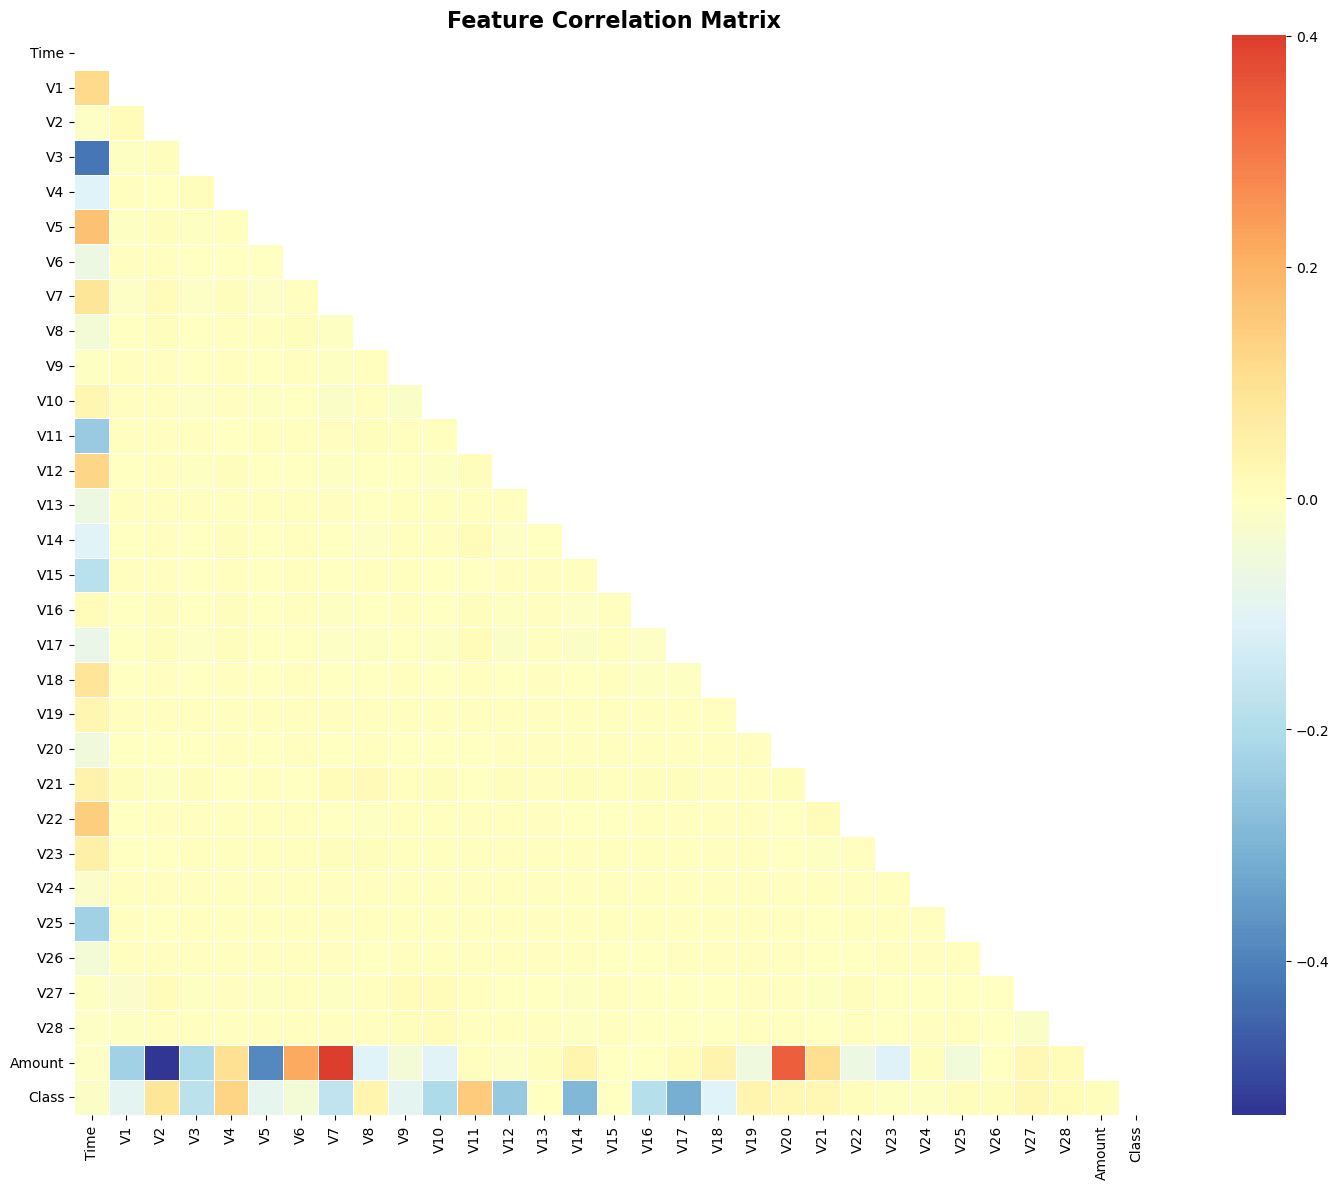

Top 10 Features Correlated with Fraud:
1. V17: 0.3135
2. V14: 0.2934
3. V12: 0.2507
4. V10: 0.2070
5. V16: 0.1872
6. V3: 0.1823
7. V7: 0.1723
8. V11: 0.1491
9. V4: 0.1293
10. V18: 0.1053


In [12]:
# Correlation Analysis
fig, ax = plt.subplots(figsize=(16, 12))

corr = df.drop('Hour', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='RdYlBu_r', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with Class
print("Top 10 Features Correlated with Fraud:")
print("=" * 40)
top_corr = corr['Class'].drop('Class').abs().sort_values(ascending=False).head(10)
for i, (feat, val) in enumerate(top_corr.items(), 1):
    print(f"{i}. {feat}: {val:.4f}")

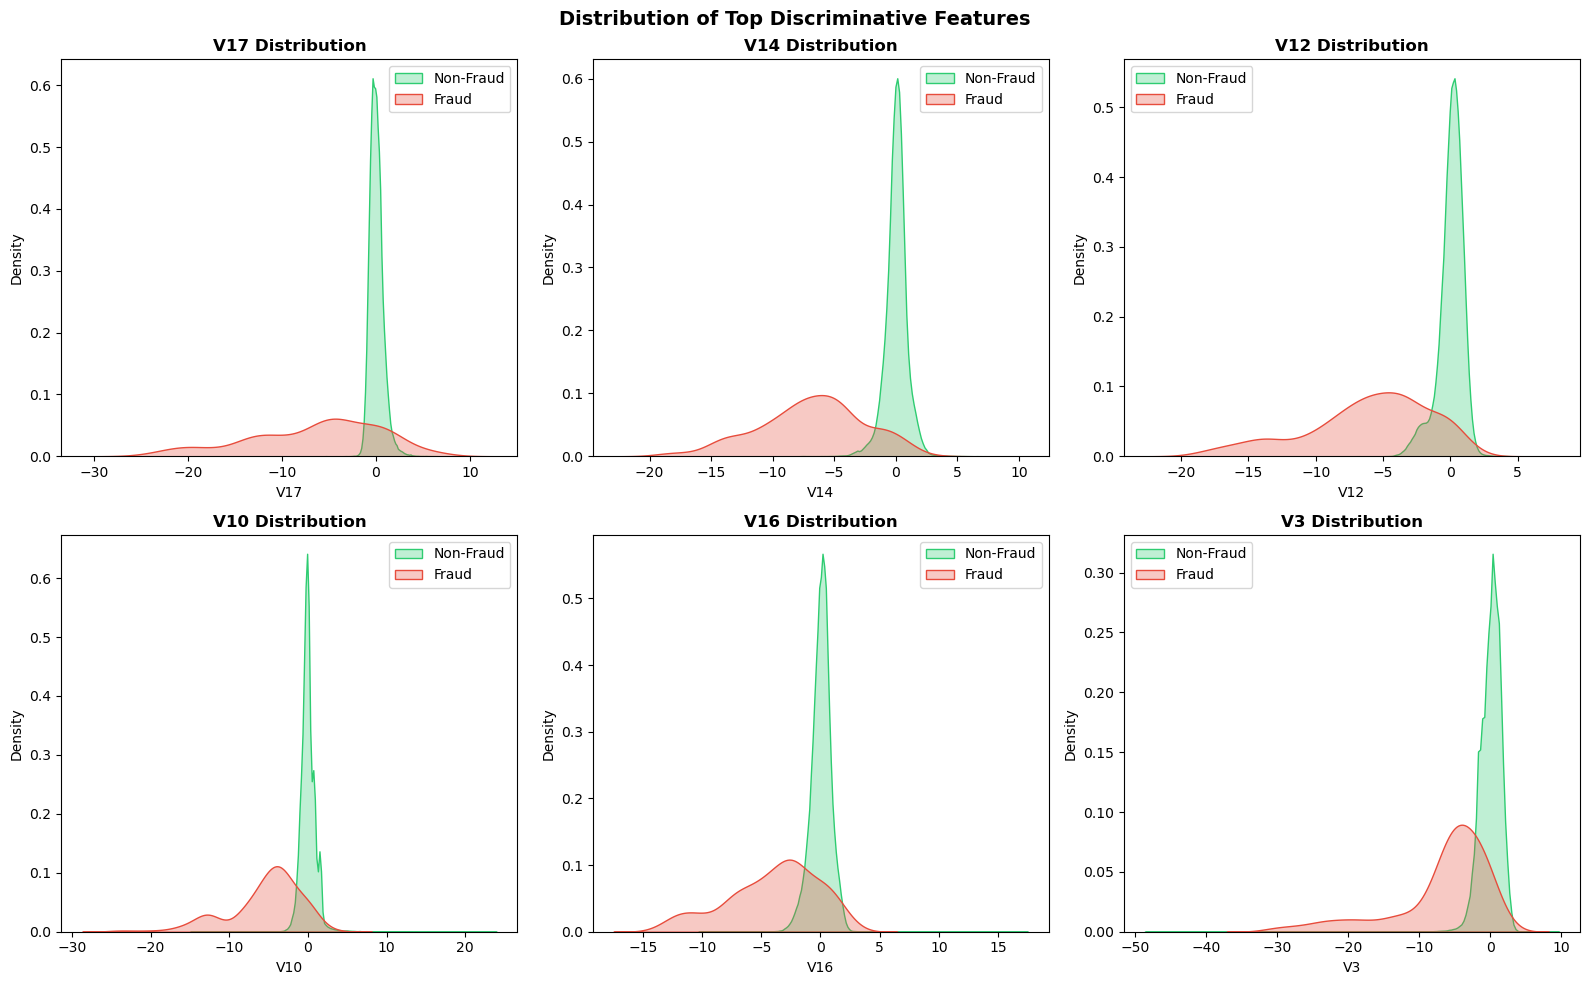

In [13]:
# Distribution of Top Features
top_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    sns.kdeplot(data=df[df['Class']==0], x=feat, ax=axes[idx], label='Non-Fraud', 
                color='#2ecc71', fill=True, alpha=0.3)
    sns.kdeplot(data=df[df['Class']==1], x=feat, ax=axes[idx], label='Fraud', 
                color='#e74c3c', fill=True, alpha=0.3)
    axes[idx].set_title(f'{feat} Distribution', fontweight='bold')
    axes[idx].legend()

plt.suptitle('Distribution of Top Discriminative Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## (4) Data Preprocessing

In [14]:
# Prepare data for modeling
print("Data Preprocessing")
print("=" * 60)

# Drop Hour column
if 'Hour' in df.columns:
    df = df.drop('Hour', axis=1)

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target distribution: {dict(y.value_counts())}")

Data Preprocessing
Features shape: (283726, 30)
Target distribution: {0: np.int64(283253), 1: np.int64(473)}


In [15]:
# Scale features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features scaled using RobustScaler")

Features scaled using RobustScaler


In [16]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"Training fraud cases: {y_train.sum()}")
print(f"Test fraud cases: {y_test.sum()}")

Training set: 226,980 samples
Test set: 56,746 samples
Training fraud cases: 378
Test fraud cases: 95


## (6) Handling Imbalanced Data

##### Machine learning models trained on imbalanced datasets tend to favor the majority class, resulting in poor detection of minority class instances. To address this, we apply **SMOTE (Synthetic Minority Over-sampling Technique)** to generate synthetic samples and improve class balance.

In [17]:
# Apply SMOTE
print("Applying SMOTE Oversampling")
print("=" * 60)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original: {X_train.shape[0]:,} samples")
print(f"Resampled: {X_train_res.shape[0]:,} samples")
print(f"New distribution: {dict(y_train_res.value_counts())}")

Applying SMOTE Oversampling
Original: 226,980 samples
Resampled: 453,204 samples
New distribution: {0: np.int64(226602), 1: np.int64(226602)}


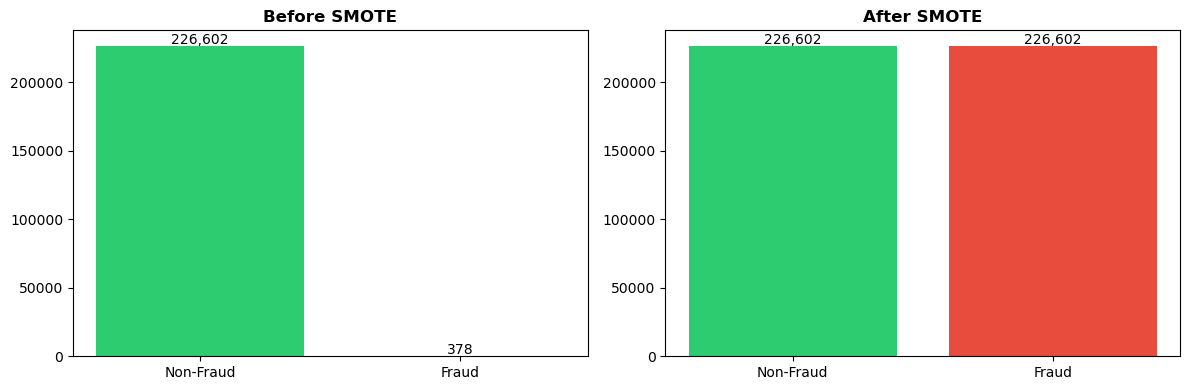

In [18]:
# Visualise SMOTE effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = y_train.value_counts()
after = y_train_res.value_counts()

axes[0].bar(['Non-Fraud', 'Fraud'], before.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Before SMOTE', fontweight='bold')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center')

axes[1].bar(['Non-Fraud', 'Fraud'], after.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE', fontweight='bold')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center')

plt.tight_layout()
plt.show()

## (7) Feature Engineering & Selection

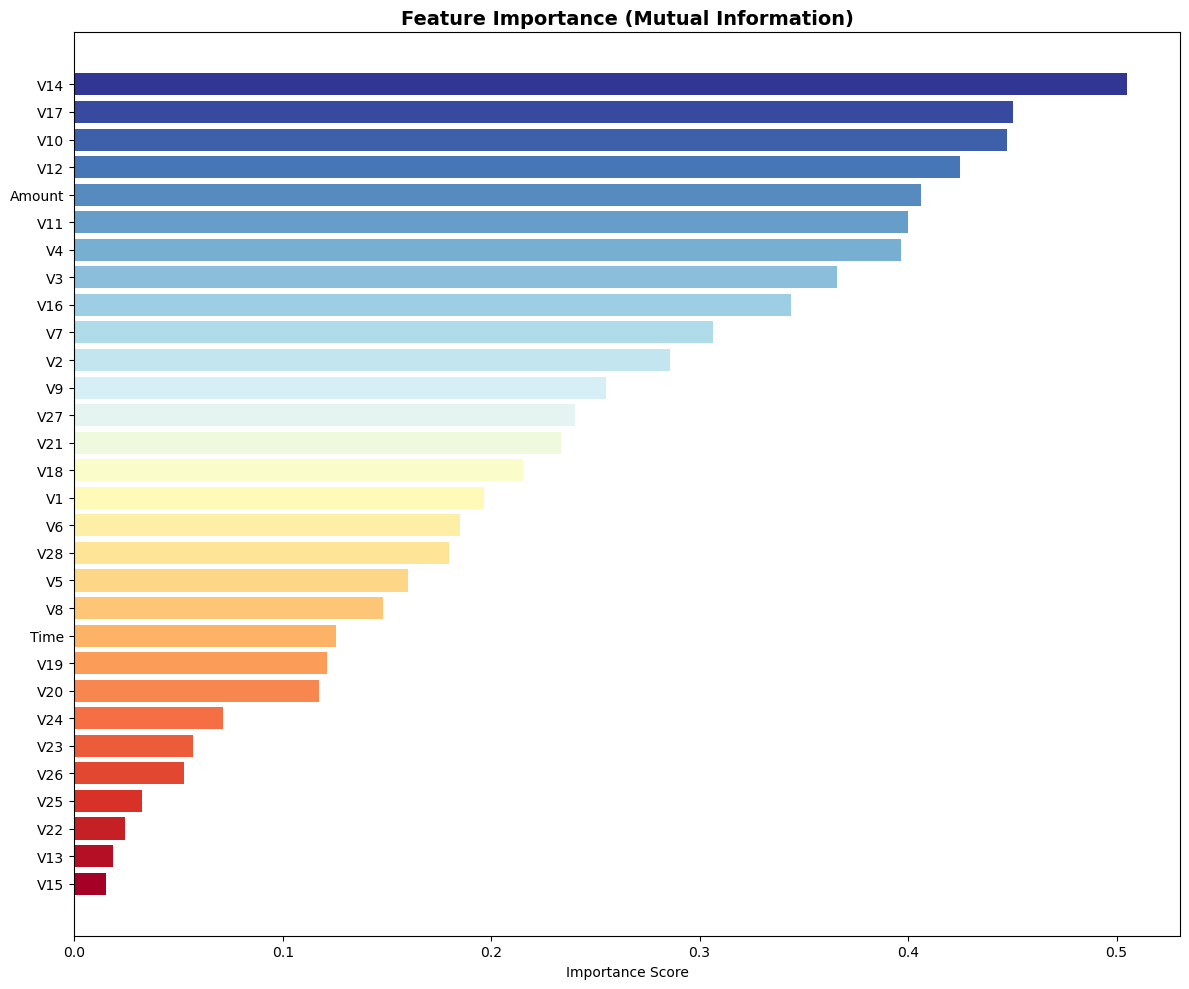

Top 10 Important Features:
Feature  Importance
     V7    0.306481
    V16    0.343914
     V3    0.365879
     V4    0.396828
    V11    0.400136
 Amount    0.406409
    V12    0.424684
    V10    0.447383
    V17    0.450222
    V14    0.505178


In [19]:
# Feature Importance using Mutual Information
mi_scores = mutual_info_classif(X_train_res, y_train_res, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'Importance': mi_scores})
mi_df = mi_df.sort_values('Importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
colors = plt.cm.RdYlBu(np.linspace(0, 1, len(mi_df)))
ax.barh(mi_df['Feature'], mi_df['Importance'], color=colors)
ax.set_title('Feature Importance (Mutual Information)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 10 Important Features:")
print(mi_df.tail(10).to_string(index=False))

## (8) Model Building & Training

In [20]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "use_label_encoder": False,
        "eval_metric": "auc"   # internal training metric (OK to keep)
    }

    model = XGBClassifier(**params)
    model.fit(X_train_res, y_train_res, eval_set=[(X_test, y_test)], verbose=False)

    y_pred_prob = model.predict_proba(X_test)[:, 1]

    auprc = average_precision_score(y_test, y_pred_prob)

    return auprc

In [21]:
# Optuna for optimising hyperparameters

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best AUPRC:", study.best_value)
print("Best Hyperparameters:", study.best_params)


[I 2026-04-06 10:28:22,362] A new study created in memory with name: no-name-2cd57267-9cfe-443c-85f8-c739e4231827


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-06 10:28:30,530] Trial 0 finished with value: 0.8097240199952765 and parameters: {'n_estimators': 277, 'max_depth': 5, 'learning_rate': 0.038889239349177415, 'subsample': 0.531148958810489, 'colsample_bytree': 0.9020794987119625, 'gamma': 2.0939770510207474, 'reg_alpha': 2.179479519536799, 'reg_lambda': 0.22568891786702183}. Best is trial 0 with value: 0.8097240199952765.
[I 2026-04-06 10:28:35,315] Trial 1 finished with value: 0.8126846502443595 and parameters: {'n_estimators': 115, 'max_depth': 12, 'learning_rate': 0.11575637079301697, 'subsample': 0.6921370660857562, 'colsample_bytree': 0.5749662497008858, 'gamma': 1.5719071695413123, 'reg_alpha': 1.474466897125712, 'reg_lambda': 1.3170888817129072}. Best is trial 1 with value: 0.8126846502443595.
[I 2026-04-06 10:28:42,874] Trial 2 finished with value: 0.8008312774543297 and parameters: {'n_estimators': 268, 'max_depth': 6, 'learning_rate': 0.03567583089148702, 'subsample': 0.8427282953204646, 'colsample_bytree': 0.51160

In [22]:
# Train final model

best_params = study.best_params

final_model = XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric="auc",
    random_state=42
)

final_model.fit(X_train_res, y_train_res)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7252217164266628
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

## (9) Threshold Optimisation

In [23]:
y_proba = final_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.30, 0.09, -0.05)  # 0.30 → 0.10

best_f1 = 0
best_threshold = None

print("\nThreshold tuning results:\n")

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    
    f1 = f1_score(y_test, preds, zero_division=0)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)

    print(f"Threshold {t:.2f} | F1: {f1:.4f} | Precision: {p:.4f} | Recall: {r:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\n✅ Best Threshold based on F1: {best_threshold:.2f}")


Threshold tuning results:

Threshold 0.30 | F1: 0.7685 | Precision: 0.7222 | Recall: 0.8211
Threshold 0.25 | F1: 0.7610 | Precision: 0.7091 | Recall: 0.8211
Threshold 0.20 | F1: 0.7536 | Precision: 0.6964 | Recall: 0.8211
Threshold 0.15 | F1: 0.7324 | Precision: 0.6610 | Recall: 0.8211
Threshold 0.10 | F1: 0.6957 | Precision: 0.5926 | Recall: 0.8421

✅ Best Threshold based on F1: 0.30


## (10) Evaluation

In [24]:
# Apply best threshold
y_pred_final = (y_proba >= best_threshold).astype(int)

print("\n📋 Final Classification Report:")
print(classification_report(y_test, y_pred_final))


📋 Final Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.82      0.77        95

    accuracy                           1.00     56746
   macro avg       0.86      0.91      0.88     56746
weighted avg       1.00      1.00      1.00     56746



##### The model achieves near-perfect overall accuracy, driven by strong performance on the majority class. While recall for fraud detection is high (0.82), indicating effective identification of fraudulent cases, precision remains moderate (0.72), suggesting a higher rate of false positives.

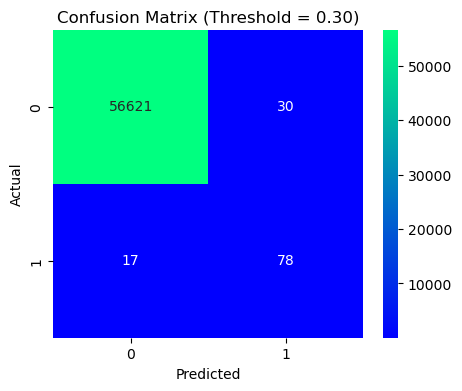

In [25]:
# Confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_final),
    annot=True,
    fmt='d',
    cmap='winter'
)

plt.title(f'Confusion Matrix (Threshold = {best_threshold:.2f})')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

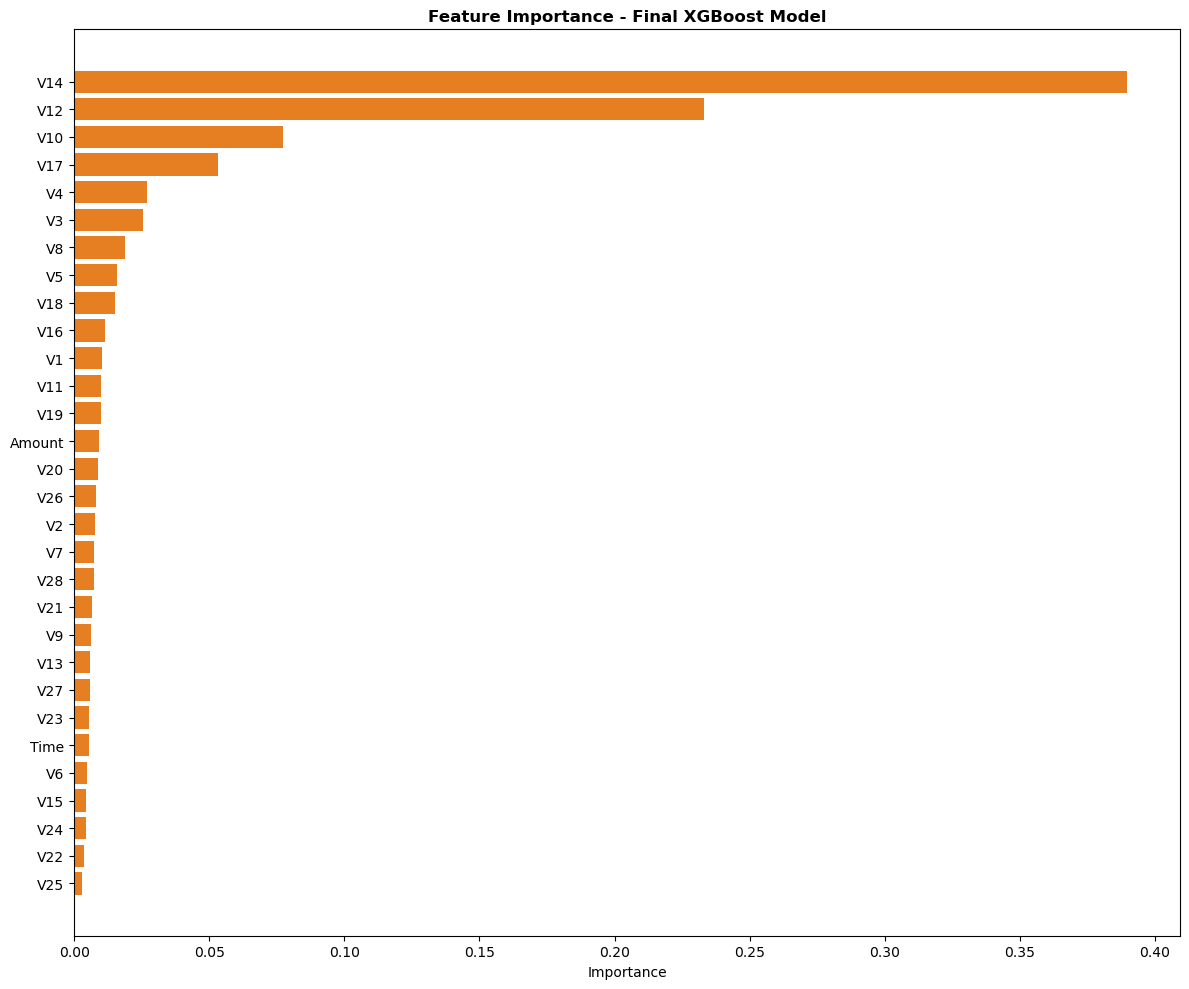

In [26]:
# Feature importance

if hasattr(final_model, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature': X_train_res.columns,  # use training feature names
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.barh(imp_df['Feature'], imp_df['Importance'], color='#e67e22')  # orange color
    ax.set_title('Feature Importance - Final XGBoost Model', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()



##### The model’s predictions are heavily driven by a small subset of features, with **V14 and V12** dominating the importance rankings, indicating strong concentration of predictive power. Most other features contribute marginally, suggesting potential redundancy or weaker signal.